Best DBSCAN → eps=0.5, min_samples=10, Silhouette=0.342
KMeans Silhouette Score   : 0.334
Spectral Silhouette Score : 0.312
DBSCAN Silhouette Score   : 0.342


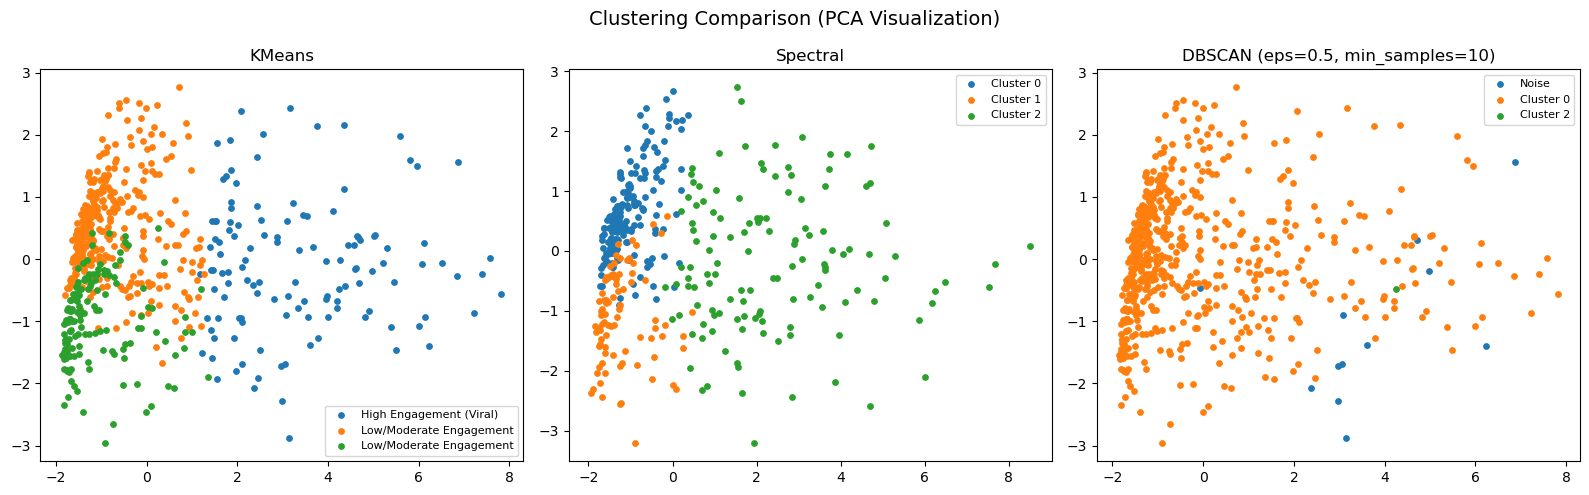

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv(r"C:\Users\Spandan\Downloads\social_media_performance.csv")
features = ['sentiment_score', 'views', 'likes', 'comments', 'shares', 'engagement_rate']
X_scaled = StandardScaler().fit_transform(df[features])

# KMeans 
km_labels = KMeans(n_clusters=3, random_state=42).fit_predict(X_scaled)
km_sil = silhouette_score(X_scaled, km_labels)

# DBSCAN Hyperparameter Tuning 
eps_values      = np.round(np.linspace(0.3, 2.5, 12), 2)
min_samples_val = [3, 5, 10, 15, 20]

best_sil, best_eps, best_ms = -1, None, None
for eps in eps_values:
    for ms in min_samples_val:
        labels     = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        mask       = labels != -1
        if n_clusters == 3 and mask.sum() > 1:
            sil = silhouette_score(X_scaled[mask], labels[mask])
            if sil > best_sil:
                best_sil, best_eps, best_ms = sil, eps, ms

# Fallback if no combo gives exactly 3 clusters
if best_eps is None:
    for eps in eps_values:
        for ms in min_samples_val:
            labels     = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_scaled)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            mask       = labels != -1
            if n_clusters >= 2 and mask.sum() > 1:
                sil = silhouette_score(X_scaled[mask], labels[mask])
                if sil > best_sil:
                    best_sil, best_eps, best_ms = sil, eps, ms

print(f"Best DBSCAN → eps={best_eps}, min_samples={best_ms}, Silhouette={best_sil:.3f}")

db_labels = DBSCAN(eps=best_eps, min_samples=best_ms).fit_predict(X_scaled)
mask  = db_labels != -1
db_sil = silhouette_score(X_scaled[mask], db_labels[mask]) if mask.sum() > 1 else 0

# Spectral 
rng  = np.random.RandomState(42)
sidx = rng.choice(len(X_scaled), 1500, replace=False)
sp_labels = SpectralClustering(
    n_clusters=3,
    affinity='nearest_neighbors',
    n_neighbors=10,
    random_state=42
).fit_predict(X_scaled[sidx])
sp_sil = silhouette_score(X_scaled[sidx], sp_labels)

# Output 
print(f"KMeans Silhouette Score   : {km_sil:.3f}")
print(f"Spectral Silhouette Score : {sp_sil:.3f}")
print(f"DBSCAN Silhouette Score   : {db_sil:.3f}")

# PCA 
X2d        = PCA(n_components=2).fit_transform(X_scaled)
sample_idx = rng.choice(len(X2d), 600, replace=False)
Xp         = X2d[sample_idx]
km_p       = km_labels[sample_idx]
db_p       = db_labels[sample_idx]

sp_sample_idx = rng.choice(len(sidx), 400, replace=False)
Xsp  = X2d[sidx][sp_sample_idx]
sp_p = sp_labels[sp_sample_idx]

# Cluster labeling(based on engagement_rate)
def label_clusters(labels, original_data):
    cluster_names = {}
    for c in np.unique(labels):
        if c == -1:
            cluster_names[c] = "Noise"
        else:
            mean_eng = original_data[labels == c]['engagement_rate'].mean()
            if mean_eng > original_data['engagement_rate'].mean():
                cluster_names[c] = "High Engagement (Viral)"
            else:
                cluster_names[c] = "Low/Moderate Engagement"
    return cluster_names

df_copy          = df.copy()
df_copy['cluster'] = km_labels
km_names         = label_clusters(km_labels, df_copy)

#  Plot 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Clustering Comparison (PCA Visualization)", fontsize=14)

for c in np.unique(km_p):
    axes[0].scatter(Xp[km_p == c, 0], Xp[km_p == c, 1],
                    s=15, label=km_names.get(c, f"Cluster {c}"))
axes[0].set_title("KMeans")
axes[0].legend(fontsize=8)

for c in np.unique(sp_p):
    axes[1].scatter(Xsp[sp_p == c, 0], Xsp[sp_p == c, 1],
                    s=15, label=f"Cluster {c}")
axes[1].set_title("Spectral")
axes[1].legend(fontsize=8)

for c in np.unique(db_p):
    label = "Noise" if c == -1 else f"Cluster {c}"
    axes[2].scatter(Xp[db_p == c, 0], Xp[db_p == c, 1],
                    s=15, label=label)
axes[2].set_title(f"DBSCAN (eps={best_eps}, min_samples={best_ms})")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()